### Техническое задание

**Задача 1**  
+ На основе данных из Построить динамику маржи по неделям.  
+ Предоставить запрос в SQL, нарисовать диаграму, указать лучшую неделю и сумму маржи.     									
  									
**Задача 2**  
+ **Рассчитать маржу в рублях и % по всей компании за август в разрезе Сайта и Приложения.**
+ **Вывести:**
  + Поля: Сайт, Приложение
  + Строки: Маржа руб, Маржа %  
*Предоставить запрос в SQL и значения*

In [113]:
#Подготовка нотбука
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
#Настройка pd для вывода больших чисел без использования научной нотации
pd.set_option('display.float_format', '{:,.2f}'.format)

Данные о заказах на листе *«Таблица t_orders»* в файле `beeline_dataset.xlsx`.</br>  
Одна строка - один заказ.  

Описание данных:
- `organization_id` - уникальный идентификатор региона
- `sales_order` - Номер заказа (2051 - сайт, 2061 - приложение)
- `date_create` - Дата и время создания заказа
- `status` - Статус заказа (0 - Выдан, остальные - Отменен)
- `code` - Код товара
- `client_id` - Код клиента
- `tvz_id` - Код точки выдачи заказа
- `cost_price` - Себестоимость
- `price_b2b_gross` - B2B цена
- `price_b2c_gross` - B2C цена
- `quantity` - Количество товара в заказе

In [114]:
#загрузка датасета 
! gdown 1WwTUjpkS8Gyp8pQ_3CEpadO3Pw-y5-3W

Downloading...
From: https://drive.google.com/uc?id=1WwTUjpkS8Gyp8pQ_3CEpadO3Pw-y5-3W
To: /Users/gasikviktor2008/beeline_dataset.xlsx
100%|██████████████████████████████████████| 2.04M/2.04M [00:01<00:00, 1.19MB/s]


In [115]:
#Создание датафрейма из Excel файла с данными
table = pd.read_excel('/Users/gasikviktor2008/beeline_dataset.xlsx', sheet_name='Таблица t_orders')

#Подключение к локальному серверу
con = sqlite3.connect('/Users/gasikviktor2008/Desktop/Beeline_case/table.sqlit')

#Загрузка датафрейма на созданный сервер
table.to_sql('t_orders', con, if_exists='replace', index=False)

27704

In [116]:
#Определения наличия пропусков и получения первичной статистики
table

,organization_id,sales_order,date_create,status,code,client_id,tvz_id,cost_price,price_b2b_gross,price_b2c_gross,quantity
0,13,2051029251,2022-08-02T16:51:03.023,0,65106,21276,7342,"20,059.87",0.00,0.00,1
1,13,2051030871,2022-08-12T08:50:06.031,2,65106,20793,7011,"20,059.87",0.00,0.00,1
2,13,2051030897,2022-08-12T10:18:02.624,3,65106,20793,7011,"20,059.87",0.00,0.00,1
3,13,2051030944,2022-08-12T13:03:03.590,0,65106,20793,7012,"20,059.87",0.00,0.00,1
4,13,2051020015,2022-06-17T16:58:02.885,0,65106,495,7104,"20,059.87",0.00,0.00,1
...,...,...,...,...,...,...,...,...,...,...,...
27699,13,2051032472,2022-08-18T10:54:03.870,3,64255,13396,7161,"13,332.45","17,076.17","18,187.27",1
27700,5,2051024243,2022-07-05T18:19:05.115,0,57759,40923,3801,"14,383.50","18,749.84","19,969.78",1
27701,5,2051032977,2022-08-19T23:53:02.457,2,1842,44470,3894,"7,860.59","12,610.47","13,431.38",1
27702,1,2051035560,2022-08-29T18:29:02.551,0,1842,29451,1277,"7,860.59","12,679.14","13,314.98",1


In [117]:
table['quantity'].describe(percentiles = [0.75, 0.9, 0.95, 0.99, 0.9999])

count     27,704.00
mean          20.34
std        3,003.98
min            1.00
50%            1.00
75%            2.00
90%            4.00
95%            6.00
99%           20.00
99.99%       213.78
max      500,000.00
Name: quantity, dtype: float64

### Методология 

**Математика рассчётов**  
Для подсчёта маржинальности в рублях используется классическая формула $\frac{P - C_p}{P}$  , где:  
+ M = маржинальность
+ P = цена
+ Cp = себестоимость

Для подсчёта маржинальности в процентах используется формула $\frac{M}{R}\cdot100\,\%$  , где:  
+ M = маржинальность
+ R = выручка

В рассчётах учитываются данные только заказов, имеющих статус равный 0 - "Выдан"

**Ограничения данных**  
В 27190 случаев в данных отсутствует однозначный признак типа клиента, по которому можно было бы сделать какой-то вывод о применной к товару цене. Поля `sales_order`(зашитый в него канал продаж в первую очередь) и quantity количество не могут служить надежными    индикаторами по следующим причинам:  
+ Канал продаж не определяет тип клиента (сайт или приложение - и юр лица и физ лица могут использовать эти каналы)
+ B2B заказы могут включать 1 единицу товара, например, если подразумевается техническая инфраструктура для облачного сервера.
+ B2C заказы могут быть на любое кол-во единиц аксессуаров  

Для коректного и асболютно точного рассчета маржинальности необходимо добавить в продакшине полe `client_type` или любым иным способом
зашить в данные информацию о типе клиента. 

**Для временного решения необходимо сделать допущение:**
На основе данных об отрасли я утверждаю, что 90-95% клиентов относятся к типу B2C.  
При случае возникновения неопределенности с определением цены, при рассчёте маржинальности к заказу будет применяться B2C значение.

### Подсчёт маржинальности в рублях по неделям 

In [118]:
result = pd.read_sql_query("""

WITH week_rated AS (
SELECT 
    organization_id, 
    sales_order, 
    status, 
    code, 
    client_id, 
    tvz_id, 
    cost_price, 
    price_b2b_gross, 
    price_b2c_gross, 
    quantity, 
    strftime('%W', date_create) as week_num,  
    (price_b2c_gross - cost_price) * quantity AS marzh_b2c
FROM t_orders
WHERE (price_b2b_gross > 0 or price_b2c_gross > 0) AND status = 0
)

SELECT 
    week_num, 
    SUM(marzh_b2c) AS total_marzh
FROM week_rated
GROUP BY week_num
ORDER BY week_num ASC

""", con)

print(result)

   week_num  total_marzh
0        22   252,110.11
1        23   510,671.95
2        24   425,072.30
3        25   510,588.25
4        26   616,817.53
5        27   576,798.97
6        28   448,465.60
7        29   349,769.97
8        30 1,547,577.49
9        31   363,650.37
10       32   445,845.76
11       33   623,268.66
12       34   550,488.07
13       35   295,681.60


### Построение диаграмы динамики маржинальности

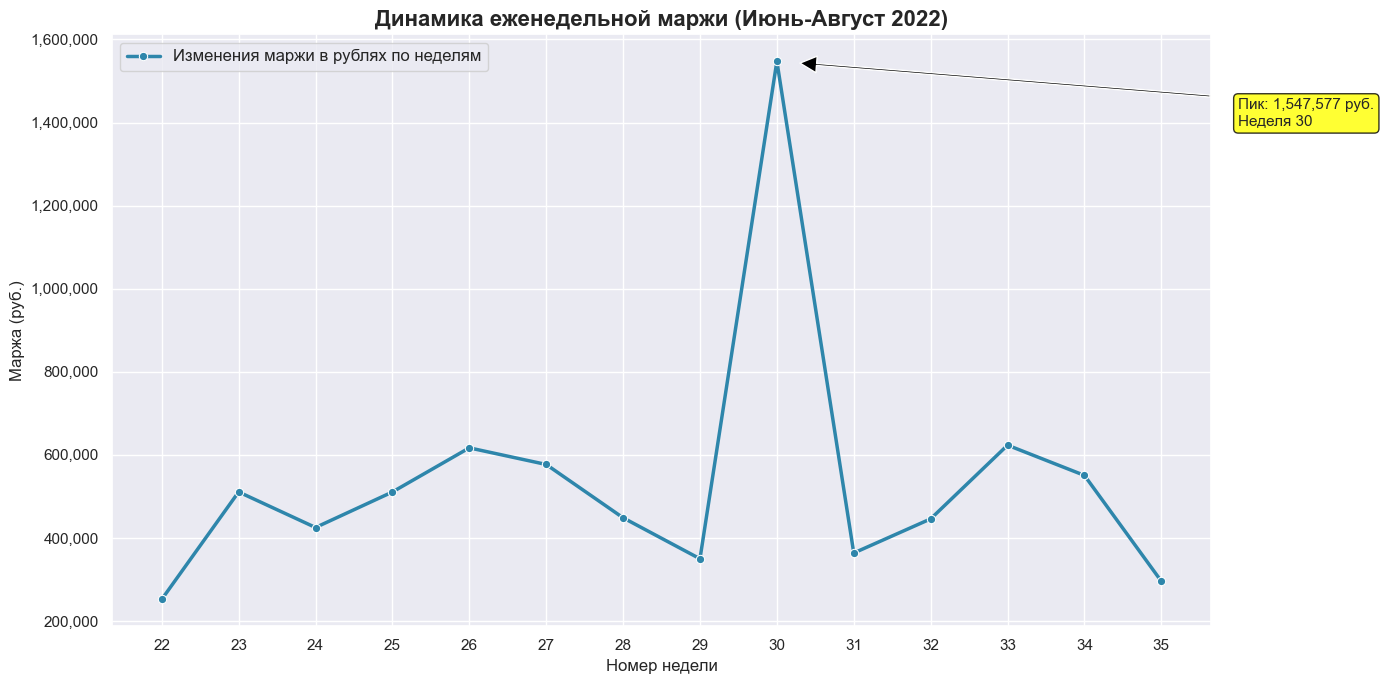


ЛУЧШАЯ НЕДЕЛЯ: 30
СУММА МАРЖИ: 1,547,577.49 руб.


In [119]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Настройка стиля
sns.set_theme(style="darkgrid")
plt.figure(figsize=(14, 7))

# Построение графика
ax = sns.lineplot(
    data=result, 
    x='week_num', 
    y='total_marzh', 
    label='Изменения маржи в рублях по неделям', 
    color='#2E86AB', 
    linewidth=2.5,
    marker='o'
)

# Оформление
plt.title('Динамика еженедельной маржи (Июнь-Август 2022)', fontsize=16, fontweight='bold')
plt.xlabel('Номер недели', fontsize=12)
plt.ylabel('Маржа (руб.)', fontsize=12)
plt.legend(fontsize=12)

# Выделение лучшей недели 
best_week_idx = result['total_marzh'].idxmax()
best_week = result.loc[best_week_idx]

plt.annotate(
    f'Пик: {int(best_week["total_marzh"]):,} руб.\nНеделя {int(best_week["week_num"])}',
    xy=(best_week['week_num'], best_week['total_marzh']),
    xytext=(best_week['week_num'] + '1', best_week['total_marzh'] * 0.9),
    arrowprops=dict(facecolor='black', shrink=0.05, width=1.5),
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.3", fc="yellow", ec="black", lw=1, alpha=0.8)
)

# Форматирование оси Y в денежный вид
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.tight_layout()
plt.show()

# Вывод итоговых цифр для отчета
print(f"\nЛУЧШАЯ НЕДЕЛЯ: {int(best_week['week_num'])}")
print(f"СУММА МАРЖИ: {best_week['total_marzh']:,.2f} руб.")

**Рассчёт маржи в рублях и процентах по всей компании за август в разрезе сайта и приложения c выводом в формате:** 
**Поля:** *Сайт, Приложение*  
**Строки:**  *Маржа руб, Маржа %*

In [120]:
result = pd.read_sql_query("""
WITH august AS (
SELECT 
    cost_price,  
    price_b2c_gross, 
    quantity, 
    CASE 
        WHEN sales_order LIKE '2061%' THEN 'app'
        WHEN sales_order LIKE '2051%' THEN 'website'
    END AS channel,
    strftime('%W', date_create) as week_num,  
    (price_b2c_gross - cost_price) * quantity AS marg
FROM t_orders
WHERE strftime('%m', date_create) = '08' AND status = 0 AND (price_b2b_gross > 0 or price_b2c_gross > 0)
),
agregated AS (
SELECT 
channel,
SUM(marg) AS marg_rub,
SUM((price_b2c_gross - cost_price) * quantity) / SUM(price_b2c_gross * quantity) * 100  AS marg_perc
FROM august
GROUP BY channel
)
SELECT 
    'Маржа руб' as '',
     SUM(CASE 
            WHEN channel = 'website' THEN marg_rub 
         END) as 'Сайт',
     SUM(CASE 
            WHEN channel = 'app' THEN marg_rub 
         END) as 'Приложение'
FROM agregated
UNION ALL
SELECT 
    'Маржа %' as '',
     SUM(CASE 
            WHEN channel = 'website' THEN marg_perc 
         END) as 'Сайт',
     SUM(CASE 
            WHEN channel = 'app' THEN marg_perc 
         END) as 'Приложение'
FROM agregated
""", con)

print(result)

                     Сайт  Приложение
0  Маржа руб 2,254,628.77   24,305.69
1    Маржа %        23.84       22.59
